In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

print("Libraries loaded!")

Libraries loaded!


In [3]:
# Customer data
data = {
    'Age': [19,21,20,23,31,22,35,23,64,30,67,35,58,24,37,22,35,20,52,35,
            35,25,46,31,54,29,45,35,40,23],
    'Annual_Income': [15,15,16,16,17,17,18,18,19,19,20,20,20,21,21,22,22,23,23,24,
                      24,25,25,28,28,29,29,30,30,33],
    'Spending_Score': [39,81,6,77,40,76,6,94,3,72,14,99,15,77,13,79,35,66,29,98,
                       35,73,5,73,14,82,32,61,31,87]
}

df = pd.DataFrame(data)
print(df.head())
print(f"\nTotal customers: {len(df)}")

   Age  Annual_Income  Spending_Score
0   19             15              39
1   21             15              81
2   20             16               6
3   23             16              77
4   31             17              40

Total customers: 30


In [5]:
# Scale data and apply KMeans
scaler = StandardScaler()
df_scaled = scaler.fit_transform(df[['Annual_Income', 'Spending_Score']])

kmeans = KMeans(n_clusters=5, random_state=42)
df['Segment'] = kmeans.fit_predict(df_scaled)

print("Segments created!")
print(df['Segment'].value_counts())

Segments created!
Segment
0    10
1     7
2     6
3     5
4     2
Name: count, dtype: int64


C:\Users\sudem\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1446: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


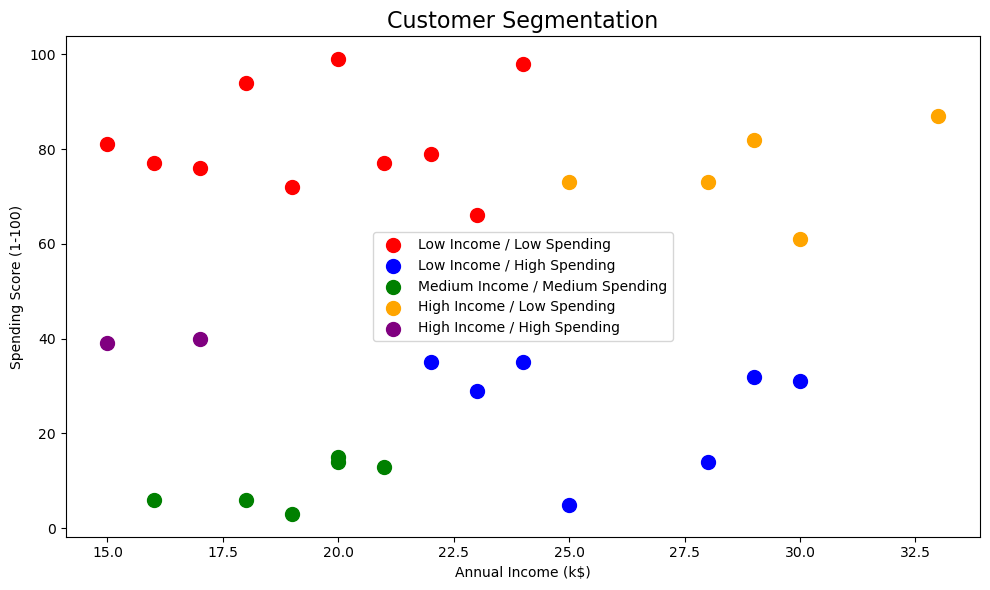

Chart saved!


In [7]:
# Visualize clusters
colors = ['red', 'blue', 'green', 'orange', 'purple']
labels = ['Low Income / Low Spending',
          'Low Income / High Spending',
          'Medium Income / Medium Spending',
          'High Income / Low Spending',
          'High Income / High Spending']

plt.figure(figsize=(10, 6))

for i in range(5):
    segment = df[df['Segment'] == i]
    plt.scatter(segment['Annual_Income'], segment['Spending_Score'],
                c=colors[i], label=labels[i], s=100)

plt.title('Customer Segmentation', fontsize=16)
plt.xlabel('Annual Income (k$)')
plt.ylabel('Spending Score (1-100)')
plt.legend()
plt.tight_layout()
plt.savefig('customer_segmentation.png', dpi=150)
plt.show()

print("Chart saved!")

In [9]:
# Segment summary
summary = df.groupby('Segment').agg({
    'Age': 'mean',
    'Annual_Income': 'mean',
    'Spending_Score': 'mean',
    'Segment': 'count'
}).rename(columns={'Segment': 'Customer_Count'}).round(1)

print("Segment Summary:")
print(summary)

Segment Summary:
          Age  Annual_Income  Spending_Score  Customer_Count
Segment                                                     
0        25.5           19.5            81.9              10
1        43.9           25.9            25.9               7
2        46.8           19.0             9.5               6
3        28.6           29.0            75.2               5
4        25.0           16.0            39.5               2
